# LAB ASSIGNMENT #01
## CIFAR-10 Image Classification using ANN/MLP + Hyperparameter Tuning


This notebook covers:
1. Data preparation (load, normalize, one-hot encode)
2. ANN/MLP model with 3 hidden layers
3. Hyperparameter tuning (Grid Search / Random Search - simple manual implementation)
4. Model training & evaluation (accuracy, loss, confusion matrix)
5. Performance comparison (plots, table of accuracy & parameter counts)
6. Optional: activation function & optimizer comparison, CNN comparison


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Data Preparation
Load CIFAR-10 (10 classes, 32x32 color images) using the Keras built-in loader.
- Normalize pixel values to [0, 1]
- One-hot encode labels
- Use the standard CIFAR-10 train/test split


In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

# Normalize images to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Flatten images for ANN/MLP (32*32*3 = 3072 features)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("Flattened train shape:", x_train_flat.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1581s 9us/step
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)
Flattened train shape: (50000, 3072)


/tmp/ipykernel_1309/313099613.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(y_train[i])])


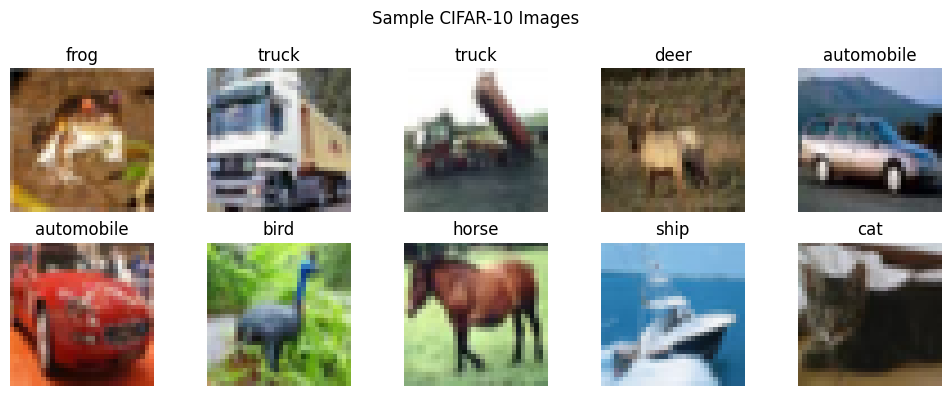

In [3]:
# Visualize a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train[i])])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()


## 3. Model Implementation: ANN with Three Hidden Layers
A simple helper function builds an MLP with 3 hidden (Dense) layers, so we can
reuse it for hyperparameter tuning.


In [4]:
def build_ann(hidden_units=(512, 256, 128), activation='relu',
              optimizer_name='adam', learning_rate=0.001, dropout_rate=0.3):
    model = models.Sequential()
    model.add(layers.Input(shape=(3072,)))

    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("Unknown optimizer")

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Quick look at architecture
sample_model = build_ann()
sample_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Hyperparameter Tuning (Grid Search)
We try a small grid of hyperparameter combinations (hidden layer sizes, learning
rate, and batch size) and train each for a few epochs to pick the best configuration.
This keeps runtime reasonable while demonstrating the tuning process.


In [5]:
param_grid = [
    {'hidden_units': (512, 256, 128), 'learning_rate': 0.001, 'batch_size': 128},
    {'hidden_units': (256, 128, 64),  'learning_rate': 0.001, 'batch_size': 128},
    {'hidden_units': (512, 256, 128), 'learning_rate': 0.0005, 'batch_size': 64},
]

TUNE_EPOCHS = 5   # kept small for hyperparameter search speed

tuning_results = []

for i, params in enumerate(param_grid):
    print(f"\n--- Grid Search Run {i+1}/{len(param_grid)}: {params} ---")
    model = build_ann(hidden_units=params['hidden_units'],
                       learning_rate=params['learning_rate'])
    start = time.time()
    hist = model.fit(x_train_flat, y_train_cat,
                      validation_split=0.1,
                      epochs=TUNE_EPOCHS,
                      batch_size=params['batch_size'],
                      verbose=0)
    elapsed = time.time() - start
    val_acc = hist.history['val_accuracy'][-1]
    tuning_results.append({**params, 'val_accuracy': val_acc, 'time_sec': elapsed})
    print(f"Validation Accuracy: {val_acc:.4f} | Time: {elapsed:.1f}s")

tuning_df = pd.DataFrame(tuning_results)
tuning_df



--- Grid Search Run 1/3: {'hidden_units': (512, 256, 128), 'learning_rate': 0.001, 'batch_size': 128} ---
Validation Accuracy: 0.3672 | Time: 103.8s

--- Grid Search Run 2/3: {'hidden_units': (256, 128, 64), 'learning_rate': 0.001, 'batch_size': 128} ---
Validation Accuracy: 0.3464 | Time: 41.1s

--- Grid Search Run 3/3: {'hidden_units': (512, 256, 128), 'learning_rate': 0.0005, 'batch_size': 64} ---
Validation Accuracy: 0.3748 | Time: 102.2s


,hidden_units,learning_rate,batch_size,val_accuracy,time_sec
0,"(512, 256, 128)",0.0010,128,0.3672,103.759111
1,"(256, 128, 64)",0.0010,128,0.3464,41.064592
2,"(512, 256, 128)",0.0005,64,0.3748,102.248112


In [6]:
best_params = tuning_df.loc[tuning_df['val_accuracy'].idxmax()]
print("Best hyperparameters found:")
print(best_params)


Best hyperparameters found:
hidden_units     (512, 256, 128)
learning_rate             0.0005
batch_size                    64
val_accuracy              0.3748
time_sec              102.248112
Name: 2, dtype: object


## 5. Model Training (Final Model)
Train the ANN with the best hyperparameters found above for a longer number of
epochs, and save the training history for plotting.


In [7]:
BEST_HIDDEN_UNITS = best_params['hidden_units']
BEST_LR = best_params['learning_rate']
BEST_BATCH = int(best_params['batch_size'])
EPOCHS = 20

final_model = build_ann(hidden_units=BEST_HIDDEN_UNITS, learning_rate=BEST_LR)

start = time.time()
history = final_model.fit(x_train_flat, y_train_cat,
                           validation_split=0.1,
                           epochs=EPOCHS,
                           batch_size=BEST_BATCH,
                           verbose=1)
training_time = time.time() - start
print(f"Total training time: {training_time:.1f} seconds")


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2327 - loss: 2.0543 - val_accuracy: 0.3182 - val_loss: 1.9061
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3032 - loss: 1.9105 - val_accuracy: 0.3494 - val_loss: 1.8066
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3186 - loss: 1.8609 - val_accuracy: 0.3446 - val_loss: 1.8006
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3311 - loss: 1.8200 - val_accuracy: 0.3636 - val_loss: 1.7605
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3434 - loss: 1.7961 - val_accuracy: 0.3890 - val_loss: 1.7175
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3515 - loss: 1.7773 - val_accuracy: 0.3876 - val_loss: 1.7102
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3567 - loss: 1.7589 - val_accuracy: 0.4042 - val_loss: 1.6791
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3648 - loss: 1.7446 - 

## 6. Model Evaluation
Evaluate test accuracy/loss and build the confusion matrix.


In [8]:
test_loss, test_acc = final_model.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 1.5934
Test Accuracy: 0.4320


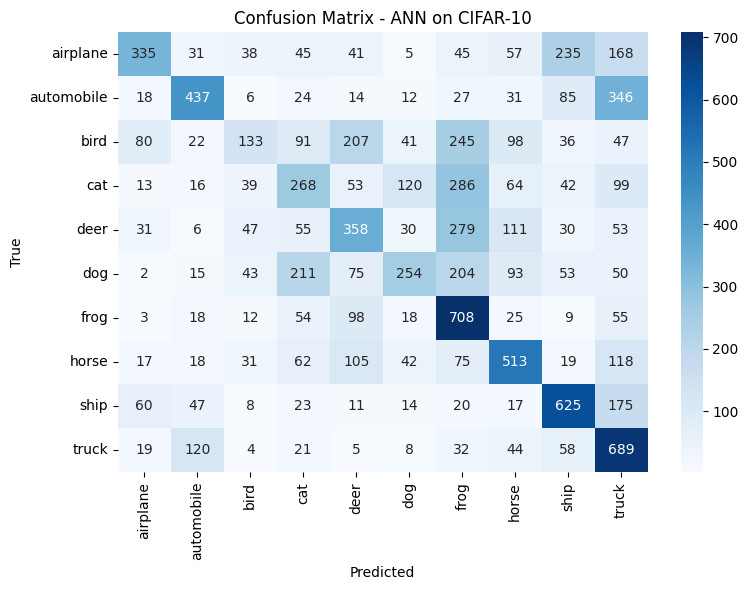

              precision    recall  f1-score   support

    airplane       0.58      0.34      0.42      1000
  automobile       0.60      0.44      0.51      1000
        bird       0.37      0.13      0.20      1000
         cat       0.31      0.27      0.29      1000
        deer       0.37      0.36      0.36      1000
         dog       0.47      0.25      0.33      1000
        frog       0.37      0.71      0.48      1000
       horse       0.49      0.51      0.50      1000
        ship       0.52      0.62      0.57      1000
       truck       0.38      0.69      0.49      1000

    accuracy                           0.43     10000
   macro avg       0.45      0.43      0.42     10000
weighted avg       0.45      0.43      0.42     10000



In [9]:
y_pred_probs = final_model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ANN on CIFAR-10')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


## 7. Performance Comparison
Plot training/validation accuracy and loss curves.


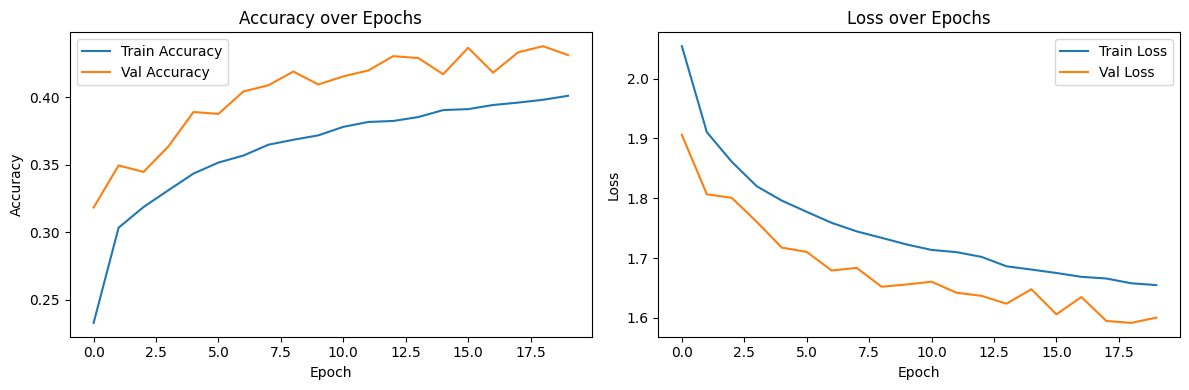

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [11]:
summary_table = pd.DataFrame([{
    'Model': 'ANN (3 hidden layers)',
    'Hidden Units': str(BEST_HIDDEN_UNITS),
    'Learning Rate': BEST_LR,
    'Batch Size': BEST_BATCH,
    'Test Accuracy': round(test_acc, 4),
    'Test Loss': round(test_loss, 4),
    'Trainable Params': final_model.count_params(),
    'Training Time (s)': round(training_time, 1)
}])
summary_table


,Model,Hidden Units,Learning Rate,Batch Size,Test Accuracy,Test Loss,Trainable Params,Training Time (s)
0,ANN (3 hidden layers),"(512, 256, 128)",0.0005,64,0.432,1.5934,1738890,543.0


## 8. Additional Challenges (Optional)
Below are optional comparisons: activation functions, optimizers, and a CNN baseline.
Each uses a shorter training run (5 epochs) since they are for comparison only.


In [12]:
# 8a. Compare activation functions (ReLU, Sigmoid, Tanh)
activations = ['relu', 'sigmoid', 'tanh']
activation_results = []

for act in activations:
    model = build_ann(activation=act)
    hist = model.fit(x_train_flat, y_train_cat, validation_split=0.1,
                      epochs=5, batch_size=128, verbose=0)
    loss, acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)
    activation_results.append({'Activation': act, 'Test Accuracy': acc, 'Test Loss': loss})

pd.DataFrame(activation_results)


,Activation,Test Accuracy,Test Loss
0,relu,0.3813,1.739912
1,sigmoid,0.3890,1.698521
2,tanh,0.3241,1.837380


In [13]:
# 8b. Compare optimizers (Adam vs SGD vs RMSProp)
opt_names = ['adam', 'sgd', 'rmsprop']
optimizer_results = []

for opt_name in opt_names:
    model = build_ann(optimizer_name=opt_name)
    hist = model.fit(x_train_flat, y_train_cat, validation_split=0.1,
                      epochs=5, batch_size=128, verbose=0)
    loss, acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)
    optimizer_results.append({'Optimizer': opt_name, 'Test Accuracy': acc, 'Test Loss': loss})

pd.DataFrame(optimizer_results)


,Optimizer,Test Accuracy,Test Loss
0,adam,0.3772,1.755862
1,sgd,0.2709,2.082734
2,rmsprop,0.3795,1.764316


In [14]:
# 8c. Try a simple CNN instead of ANN and compare accuracy
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_history = cnn_model.fit(x_train, y_train_cat, validation_split=0.1,
                             epochs=5, batch_size=128, verbose=1)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

print(f"CNN Test Accuracy: {cnn_acc:.4f} vs ANN Test Accuracy: {test_acc:.4f}")

comparison = pd.DataFrame([
    {'Model': 'ANN (3 hidden layers)', 'Test Accuracy': test_acc, 'Params': final_model.count_params()},
    {'Model': 'CNN (2 conv blocks)', 'Test Accuracy': cnn_acc, 'Params': cnn_model.count_params()}
])
comparison


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 229ms/step - accuracy: 0.4182 - loss: 1.6183 - val_accuracy: 0.5638 - val_loss: 1.2660
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 229ms/step - accuracy: 0.5529 - loss: 1.2579 - val_accuracy: 0.6172 - val_loss: 1.0970
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 221ms/step - accuracy: 0.6039 - loss: 1.1194 - val_accuracy: 0.6514 - val_loss: 1.0018
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 220ms/step - accuracy: 0.6358 - loss: 1.0332 - val_accuracy: 0.6602 - val_loss: 0.9833
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 76s 215ms/step - accuracy: 0.6587 - loss: 0.9717 - val_accuracy: 0.6776 - val_loss: 0.9144
CNN Test Accuracy: 0.6656 vs ANN Test Accuracy: 0.4320


,Model,Test Accuracy,Params
0,ANN (3 hidden layers),0.4320,1738890
1,CNN (2 conv blocks),0.6656,545098
